# Bushfire spread CA - the model and its validation

**CITS4403 Computational Modelling · notebook 01 of 03**

This notebook explains the model that every later experiment runs, shows it running live, shows the test suite that guards it, and validates it against a known result. It has five parts:

1. [The model at a glance](#1.-The-model-at-a-glance): lattice, states, the two regimes
2. [The transition rule](#2.-The-transition-rule): initialisation and the update equations
3. [The wind kernel](#3.-The-wind-kernel): the 3×3 weights that make spread directional
4. [A live demonstration](#4.-A-live-demonstration): one small fire, run here and now
5. [The invariant suite](#5.-The-invariant-suite) and [the Experiment 0 validation](#6.-Validation:-Experiment-0)

**How this notebook relates to the rest of the project.** It is a *consumer*, not a second source of truth. Every figure comes from the registry in `figures/make_figures.py` (`FIGURES`), which reads `results/` and never runs the simulator. The single exception is the live demonstration in part 4, which is labelled as a demonstration and feeds no reported quantity. Every number quoted in prose comes from `results/` or from a cell that computes it visibly.

**To run it.** From the repository root, once:

```bash
python run.py --exp 0        # writes results/exp0.parquet and results/pc_estimates.parquet
```

then *Restart & Run All*. The notebook is committed with its outputs stored, so it reads without running.

In [1]:
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Work from the repository root wherever Jupyter was launched, so `src`, `figures`
# and the relative `results/` paths used by the test suite all resolve.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from figures.make_figures import CAPTIONS, FIGURES, SERIES_COLOURS, STYLE
from src.model import (BURNING, BURNT, DIAGONAL_FACTOR, EMPTY, FUEL, NEIGHBOURS,
                       P_C_LITERATURE, SETTLEMENT, wind_weights)

for needed in ("exp0.parquet", "pc_estimates.parquet"):
    if not (ROOT / "results" / needed).exists():
        raise FileNotFoundError(f"results/{needed} is missing; run `python run.py --exp 0` first")
print(f"repository root: {ROOT.name}/   figures registered: {', '.join(FIGURES)}")

repository root: bushfire-ca/   figures registered: validation


## 1. The model at a glance

A stochastic two-dimensional **cellular automaton** of a single fire event. The landscape is an $L \times L$ lattice of cells with a **Moore (8-cell) neighbourhood**. Boundaries are **absorbing and non-periodic**: a fire that reaches an edge simply leaves the domain, so there is no wraparound and finite-size effects are handled by finite-size scaling rather than hidden by periodic boundaries.

Each cell is in one of five states (`int8`):

| state | value | meaning |
|---|---|---|
| `EMPTY` | 0 | no fuel; never burns, never propagates |
| `FUEL` | 1 | unburnt fuel, load $f > 0$ |
| `BURNING` | 2 | currently alight |
| `BURNT` | 3 | absorbing within one fire event |
| `SETTLEMENT` | 4 | non-fuel; never burns, never propagates; used only for the settlement metric |

Alongside the state, a separate float grid $f$ holds the **fuel load**: $f = 1$ for untreated fuel, $f = f_{\text{treat}}$ (default 0.2) for fuel that a prescribed burn has reduced, and $f = 0$ for `EMPTY` and `SETTLEMENT` cells. A **treatment** changes a cell's fuel load, never its state.

The scientific question is whether the *spatial arrangement* of a fixed treatment budget shifts the system's critical fuel density, or only reduces burn size away from it. To ask that, the model is used in **two regimes of the same code, which must not be conflated**:

| | `PERCOLATION` | `STUDY` |
|---|---|---|
| purpose | validation against a known baseline | every substantive experiment |
| $\beta$ (spread strength) | 1.0 | 0.8 |
| $\kappa$ (wind concentration) | 0 | 0, 1, 2, 4 |
| diagonal distance factor | off | on |
| treatment | none ($b = 0$) | $f_{\text{treat}} = 0.2$, budget $b$ of the *occupied* cells |
| ignition | the whole top edge (`"edge"`) | one random fuel cell (`"random_cell"`) |

In [2]:
states = pd.DataFrame(
    {"name": ["EMPTY", "FUEL", "BURNING", "BURNT", "SETTLEMENT"],
     "value": [EMPTY, FUEL, BURNING, BURNT, SETTLEMENT]}
).set_index("name")
display(states.T)
print("NEIGHBOURS, (dy, dx), in the fixed order the wind weights are indexed by:")
print(NEIGHBOURS)

name,EMPTY,FUEL,BURNING,BURNT,SETTLEMENT
value,0,1,2,3,4


NEIGHBOURS, (dy, dx), in the fixed order the wind weights are indexed by:
[(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]


## 2. The transition rule

### Initialisation

1. If the run has a settlement, a square block of cells is set to `SETTLEMENT`.
2. Every other cell is occupied **independently with probability $p$**: occupied cells become `FUEL`, the rest `EMPTY`.
3. A treatment geometry marks a set of *occupied* cells, which get $f = f_{\text{treat}}$. Occupancy is drawn **before** treatment, because a generator must see the realised occupancy to hit an exact budget.
4. Ignite: either every `FUEL` cell in row 0 (`"edge"`), or one `FUEL` cell chosen uniformly at random (`"random_cell"`).

### One synchronous step

Time is discrete and every cell updates at once. Let $B$ be the set of cells that are currently `BURNING`.

1. For each of the 8 neighbour offsets $d$, a burning cell attempts to ignite its neighbour in direction $d$ with probability

$$P_d(j) \;=\; \operatorname{clip}\!\big(\beta \, w_d \, f[j],\; 0,\; 1\big)$$

   where $\beta$ is the spread strength, $w_d$ is the wind weight for direction $d$ (part 3) and $f[j]$ is the fuel load of the **target** cell $j$.

2. A cell $j$ in state `FUEL` is the target of up to eight such attempts, one from each burning neighbour. It ignites if **at least one** succeeds:

$$P(j \text{ ignites}) \;=\; 1 \;-\; \prod_{d \,:\, j\text{'s neighbour in direction } -d \text{ is burning}} \big(1 - P_d(j)\big)$$

   (The burner that attacks $j$ in direction $d$ sits at $j - d$, which is why the product runs over $j$'s neighbour in direction $-d$.) In code this is a running product of $(1 - P_d)$ over the eight shifted burning masks, then **one Bernoulli draw over the whole grid**.

3. Every cell in $B$ increments its `burn_clock`. A cell with $\texttt{burn\_clock} \ge \tau$ becomes `BURNT`.
4. Cells that ignited this step become `BURNING`.

The run stops when no cell is `BURNING`, or at `max_steps` $= 8L$ (a run that stops there with fire still alive is flagged `truncated`, and no truncated run may appear in any reported result).

**Semantics that are easy to get wrong, and are preserved exactly:**

- Probabilities are computed from the burning set *at the start of the step*. A cell that ignites this step does not spread until the next one.
- A cell that becomes `BURNT` this step *did* get to attempt ignition this step (step 1 runs before step 3).
- Only `FUEL` cells can ignite. `EMPTY`, `BURNT` and `SETTLEMENT` cells never do.
- `burned_cells` counts `BURNT` cells only; cells still `BURNING` at truncation are counted separately.

### Why the `PERCOLATION` regime is a clean test

With $\beta = 1$, $\kappa = 0$, no diagonal factor and untreated fuel ($f = 1$), every weight is $w_d = 1$ and so $P_d(j) = 1$ for every occupied neighbour of a burning cell. The burned region is then *exactly* the connected cluster of occupied cells that contains the ignition: the model reduces to **site percolation on a square lattice with Moore connectivity**, whose threshold is known, $p_c \approx 0.407$ (`P_C_LITERATURE`). Changing $\beta$, $\kappa$ or the diagonal factor breaks that reduction, which is why those settings are not negotiable in this regime.

## 3. The wind kernel

The weights $w_d$ are indexed by the neighbour offsets in the fixed order of `NEIGHBOURS`, $(dy, dx)$ with $+y$ pointing *down* the array. To make north point up in physical coordinates the direction of each offset is $\theta_d = \operatorname{atan2}(-dy,\, dx)$, and with wind direction $\varphi$ ($\varphi = 0$ is east, $+x$) the weights have **von Mises** form:

$$\text{raw}_d \;=\; \exp\!\big(\kappa \cos(\theta_d - \varphi)\big)\cdot\begin{cases}\text{DIAGONAL\_FACTOR} & d \text{ diagonal and diagonal\_factor on}\\[2pt] 1 & \text{otherwise}\end{cases}
\qquad
w_d \;=\; \frac{\text{raw}_d}{\operatorname{mean}_{d'}(\text{raw}_{d'})}$$

- $\kappa \ge 0$ is the **concentration** of the wind: $\kappa = 0$ is no wind, larger $\kappa$ funnels spread towards $\varphi$.
- $\text{DIAGONAL\_FACTOR} = 1/\sqrt{2} \approx 0.7071$. Spread rate should fall with distance; without it Moore-neighbourhood spread is $\sqrt{2}$ faster along diagonals and fire fronts come out square instead of round.
- **The weights are normalised to mean 1, not to sum 1.** The mean-1 form means $\kappa$ changes the *anisotropy* of spread without changing its mean rate. Normalising to sum 1 would couple wind strength to overall flammability and confound $\kappa$ with $\beta$.

Below, `wind_weights` evaluated for three settings and laid out as the $3\times3$ neighbourhood around a burning cell (the centre is the burning cell itself, which has no weight). Rows are $dy$, columns are $dx$.

In [3]:
def kernel_grid(kappa, phi, diagonal_factor):
    # Lay the 8 weights out on the 3x3 neighbourhood: NEIGHBOURS[i] = (dy, dx) -> cell [dy+1, dx+1].
    w = wind_weights(kappa, phi, diagonal_factor)
    grid = np.full((3, 3), np.nan)
    for (dy, dx), weight in zip(NEIGHBOURS, w):
        grid[dy + 1, dx + 1] = weight
    frame = pd.DataFrame(grid,
                         index=["dy = -1  (north)", "dy = 0", "dy = +1  (south)"],
                         columns=["dx = -1  (west)", "dx = 0", "dx = +1  (east)"])
    return frame, w

settings = [
    ("PERCOLATION: kappa = 0, no diagonal factor  ->  all weights 1", 0.0, 0.0, False),
    ("STUDY, no wind: kappa = 0, diagonal factor on  ->  diagonals weigh 1/sqrt(2) as much, mean still 1", 0.0, 0.0, True),
    ("STUDY, wind towards east: kappa = 2, phi = 0, diagonal factor on", 2.0, 0.0, True),
]
for title, kappa, phi, diag in settings:
    frame, w = kernel_grid(kappa, phi, diag)
    display(frame.style.format(precision=3, na_rep="—").set_caption(title))
    print(f"   mean of the 8 weights = {w.mean():.6f}   (DIAGONAL_FACTOR = {DIAGONAL_FACTOR:.4f})\n")

,dx = -1 (west),dx = 0,dx = +1 (east)
dy = -1 (north),1.000,1.000,1.000
dy = 0,1.000,—,1.000
dy = +1 (south),1.000,1.000,1.000


   mean of the 8 weights = 1.000000   (DIAGONAL_FACTOR = 0.7071)



,dx = -1 (west),dx = 0,dx = +1 (east)
dy = -1 (north),0.828,1.172,0.828
dy = 0,1.172,—,1.172
dy = +1 (south),0.828,1.172,0.828


   mean of the 8 weights = 1.000000   (DIAGONAL_FACTOR = 0.7071)



,dx = -1 (west),dx = 0,dx = +1 (east)
dy = -1 (north),0.088,0.510,1.483
dy = 0,0.069,—,3.769
dy = +1 (south),0.088,0.510,1.483


   mean of the 8 weights = 1.000000   (DIAGONAL_FACTOR = 0.7071)



Reading the third grid: the east cell carries the largest weight and the west cell the smallest, so a burning cell is far likelier to ignite its eastern neighbour than its western one. The four diagonals are down-weighted by the diagonal factor on top of the wind. The mean of the eight weights is 1 in every case, which is the normalisation doing its job.

## 4. A live demonstration

> **This is a demonstration, not a result.** It runs the model live at a small lattice size with a fixed seed, so that the update rule can be *seen*. It is the only place in this notebook that runs the simulator (`L` is capped at 128 and the cell checks it), and **no reported quantity comes from it**. Every number and figure in the report comes from `results/`, via `figures/make_figures.py`.

Two fires are run on **the same landscape**. Because both use the same seed, the occupancy draw and the random ignition cell are identical, so the only thing that differs is the wind: $\kappa = 0$ against $\kappa = 2$ with the wind towards east ($\varphi = 0$). Each burnt cell is coloured by `ignition_step`, the step at which it first caught fire, which turns the final scar into a space-time picture of the front. Edit the settings and re-run *this cell only* to experiment.

,kappa = 0,kappa = 2
"ignition cell (y, x)","(22, 7)","(22, 7)"
burned cells,8240,3326
burned fraction of lattice,0.503,0.203
steps to extinction,184,133
truncated,False,False


both runs together took 43 ms


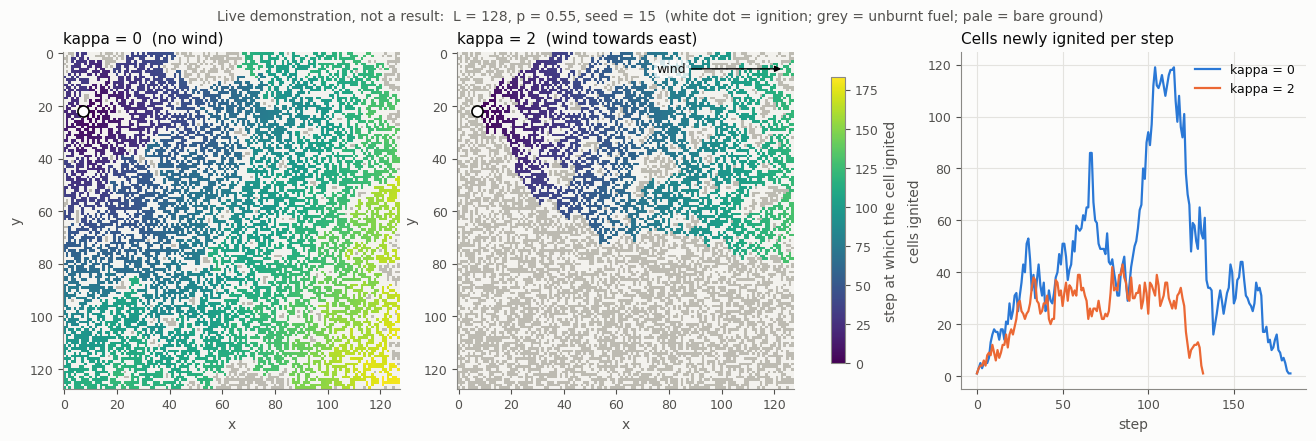

In [4]:
from src import model   # the one place this notebook runs the model: a seeded demonstration (L <= 128)

# --- demonstration settings: edit and re-run this cell ----------------------
L, P, SEED = 128, 0.55, 15          # lattice side, occupancy probability, fixed seed
KAPPAS, PHI = (0.0, 2.0), 0.0       # the two wind strengths compared; wind blows towards east
assert L <= 128, "the live demonstration is bounded at L <= 128"

t0 = time.perf_counter()
runs = {k: model.run_fire(model.Config(L=L, p=P, kappa=k, phi=PHI, seed=SEED), capture_scar=True)
        for k in KAPPAS}
elapsed = time.perf_counter() - t0
assert elapsed < 10, f"demonstration took {elapsed:.1f}s; it must stay under 10s"

summary = pd.DataFrame({
    f"kappa = {k:g}": {
        "ignition cell (y, x)": (r.ignition_y, r.ignition_x),
        "burned cells": r.burned_cells,
        "burned fraction of lattice": round(r.burned_cells / r.n_cells, 3),
        "steps to extinction": r.steps,
        "truncated": r.truncated,
    } for k, r in runs.items()})
display(summary)
print(f"both runs together took {elapsed * 1000:.0f} ms")

# --- space-time view --------------------------------------------------------
GROUND = {EMPTY: "#f3f2ee", FUEL: "#bdbbb2"}        # bare ground, unburnt fuel
LINES = ["#2a78d6", "#eb6834"]                       # slots 1-2 of the shared palette

def backdrop(scar):
    img = np.zeros(scar.shape + (3,))
    for state, colour in GROUND.items():
        img[scar == state] = mpl.colors.to_rgb(colour)
    return img

last_step = max(int(r.ignition_step.max()) for r in runs.values())
with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), layout="constrained")
    for ax, (k, r) in zip(axes[:2], runs.items()):
        ax.imshow(backdrop(r.scar), interpolation="nearest")
        im = ax.imshow(np.ma.masked_less(r.ignition_step, 0), cmap="viridis", vmin=0, vmax=last_step,
                       interpolation="nearest")
        ax.plot(r.ignition_x, r.ignition_y, "o", ms=8, mfc="white", mec="black", mew=1.2)
        ax.set_title(f"kappa = {k:g}" + ("  (no wind)" if k == 0 else "  (wind towards east)"))
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(False)
        if k > 0:
            ax.annotate("wind", xy=(0.97, 0.95), xytext=(0.68, 0.95), xycoords="axes fraction",
                        ha="right", va="center", fontsize=9,
                        arrowprops=dict(arrowstyle="-|>", color="black"),
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
    fig.colorbar(im, ax=axes[:2], shrink=0.85, label="step at which the cell ignited")

    for colour, (k, r) in zip(LINES, runs.items()):
        newly = np.bincount(r.ignition_step[r.ignition_step >= 0])
        axes[2].plot(np.arange(newly.size), newly, color=colour, label=f"kappa = {k:g}")
    axes[2].set_title("Cells newly ignited per step")
    axes[2].set_xlabel("step"); axes[2].set_ylabel("cells ignited"); axes[2].legend()
    fig.suptitle(f"Live demonstration, not a result:  L = {L}, p = {P}, seed = {SEED}  "
                 "(white dot = ignition; grey = unburnt fuel; pale = bare ground)",
                 fontsize=10, color="#52514e")

What to look for in the picture:

- **Same landscape, different fire.** The grey patches left unburnt are the same fuel bed in both panels; only the kernel changed. Without wind the front advances in every direction and burns a large share of the lattice. With wind towards east the burn is a wedge that extends downwind to the east edge, and the table above shows it is also a *smaller* fire. That is the mean-1 normalisation at work: the weights average to 1, so wind *redistributes* spread (more towards the east, less towards the west and across the wind) rather than adding to it, and at an occupancy this close to the threshold the lost upwind and crosswind spread costs more than the downwind gain. This is a single draw and says nothing in general about how $\kappa$ changes burn size; measuring that properly is what the experiments are for.
- **The front is visible.** Colour grows outward from the white ignition dot in steps of one cell per step at most: a burning cell only ever ignites its immediate neighbours, and a cell ignited this step does not spread until the next. The step colours are therefore a map of travel time from the ignition cell.
- **Fires end on their own.** The right-hand panel shows the number of newly ignited cells per step. It rises while the front lengthens and falls as the fire runs out of reachable fuel, until no cell is `BURNING` and the run stops.
- **Fixed seed, fixed fire.** Re-running the cell reproduces both fires exactly, because `run_fire` builds its own generator from `cfg.seed` (invariant I2, below).

One fire is an anecdote. The experiments use hundreds to thousands of replicates per configuration so that statements are about distributions, not single draws.

## 5. The invariant suite

A model like this produces plausible-looking numbers whatever it is fed, so a silent error does not announce itself. The defence is a test suite of **eleven invariants (I1–I11)** that pin down properties the model must have. They are asserted in `tests/test_invariants.py`, **and only there**; this notebook explains them and shows the test run, it does not re-implement any of them.

| | invariant | what the test asserts | why it matters |
|---|---|---|---|
| **I1** | Percolation limit | the `PERCOLATION` finite-size-scaling crossing $p_c$ lies within 0.01 of the literature 0.407 | the whole chain (rule, harness, estimator) recovers one independently known number |
| **I2** | Determinism | the same `Config` run twice gives an identical result, every field and the scar | `run_fire` seeds its own generator, so every number is reproducible and runs can be resumed |
| **I3** | Deterministic front shape | at $p = 1$, $\beta = 1$, $\kappa = 0$, no diagonal factor, each cell ignites at exactly its Chebyshev distance from the ignition cell | with randomness removed, the synchronous update and the Moore neighbourhood must give a perfect square front |
| **I4** | Isotropy | at $\kappa = 0$ the second moments of the scar in $x$ and $y$ agree within a 99% interval over 200 replicates | catches any axis bias in the step function |
| **I5** | Wind monotonicity | the mean scar centroid, projected on the wind direction, strictly increases over $\kappa \in \{0, 1, 2, 4\}$ | the kernel points the right way and stronger wind pushes the fire further downwind |
| **I6** | Null treatment | at $b = 0$, every treatment condition gives byte-identical results for the same seed | a generator that touches the random stream when it has nothing to treat would make the $b=0$ baselines differ for no physical reason |
| **I7** | Budget parity | `n_treated` is within tolerance of $\text{round}(b \cdot n_{\text{occupied}})$ for every condition | the efficiency metric divides by the *realised* treated count, so it must track the nominal budget |
| **I8** | Treatment placement | no treated cell is unoccupied | you cannot prescribe-burn bare ground; a violation would make $b$ incomparable across fuel densities |
| **I9** | Conservation | `burned_cells + still_burning_cells` never exceeds `n_occupied`; cells still alight at truncation are not folded into the burnt total | the prototype's bug; this keeps burned area honest |
| **I10** | No truncation | the analysis layer *refuses* a frame containing a truncated run, rather than filtering the row out | a truncated fire is a wrong answer, and silently dropping it biases the distribution |
| **I11** | Lattice frame invariance | the gap between strips perpendicular and parallel to the wind does not depend on the wind being axis-aligned | separates a real geometry effect from an artefact of the square lattice |

The suite, run from this notebook (`pytest` output, verbatim):

In [5]:
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_invariants.py", "-v",
     "--no-header", "--disable-warnings", "--color=no", "-p", "no:cacheprovider"],
    cwd=ROOT, capture_output=True, text=True,
)
print(proc.stdout.rstrip())
if proc.stderr.strip():
    print(proc.stderr.rstrip())
print(f"\npytest exit code: {proc.returncode}")

============================= test session starts =============================
collecting ... collected 13 items

tests/test_invariants.py::test_i1 PASSED                                 [  7%]
tests/test_invariants.py::test_i2_determinism PASSED                     [ 15%]
tests/test_invariants.py::test_i3_deterministic_front_is_square PASSED   [ 23%]
tests/test_invariants.py::test_i9_conservation PASSED                    [ 30%]
tests/test_invariants.py::test_i4_isotropy PASSED                        [ 38%]
tests/test_invariants.py::test_i5_wind_monotonicity PASSED               [ 46%]
tests/test_invariants.py::test_i6_null_treatment[open] PASSED            [ 53%]
tests/test_invariants.py::test_i6_null_treatment[settlement] PASSED      [ 61%]
tests/test_invariants.py::test_i7_budget_parity PASSED                   [ 69%]
tests/test_invariants.py::test_i8_treatment_placement PASSED             [ 76%]
tests/test_invariants.py::test_i9 XFAIL (I9 conservation lands in SP...) [ 84%]
tests

How to read it:

- **`PASSED`**: the invariant holds. Note that `test_i1` reads the committed Experiment 0 results, `test_i10` builds real runs (one that finishes, one deliberately cut off by `max_steps`) and checks that the analysis layer passes the first and refuses the second, and I6 runs in two settings, open lattice and with a settlement.
- **`XFAIL`**: *expected* failures, and the notebook does not claim them. `test_i9` is a leftover placeholder from the repository skeleton; conservation is asserted for real by `test_i9_conservation`, which passes. `test_i11` is a placeholder that belongs to a later piece of work (frame invariance is measured alongside Experiments 3 and 4), so at the time this notebook was run **I11 is not yet verified**.
- The slow tests (I4 and I5, 200 replicates each) are included, which is why this cell takes several seconds. The "2 warnings" in the summary line are pytest noting that the `slow` marker is not registered; they are cosmetic.
- A non-zero exit code or a `FAILED` line would mean an invariant is broken, and nothing in the report should be trusted until it is fixed.

## 6. Validation: Experiment 0

The unit asks for a replication of a known baseline. Experiment 0 provides it, through the `PERCOLATION` regime of part 2, in which the model reduces exactly to site percolation on a Moore-neighbourhood square lattice.

**Design.** Fuel density $p$ is swept from 0.30 to 0.60 in steps of 0.005, at lattice sizes $L \in \{128, 256, 512\}$, with 500 replicates per point. Every run ignites the whole top edge and records whether the fire **spanned** the lattice, that is, whether any cell in the bottom row burned. The spanning probability $P(\text{span})$ against $p$ is a sigmoid whose midpoint is the percolation threshold, and the question is whether the measured threshold matches the literature.

**Method.** A threshold measured on one finite lattice is biased: the transition is smeared over a width that shrinks only as $L^{-1/\nu}$ (with $\nu = 4/3$ for two-dimensional percolation), so a single-size estimate sits off the true value. The standard remedy is **finite-size scaling**. At the critical point $P(\text{span})$ is independent of $L$, so the curves for different sizes **cross** there, while away from it larger lattices make the transition sharper. The estimate is therefore the crossing point of the curves across $L$, with a bootstrap standard error. The location of the peak of $\operatorname{Var}(\text{burned fraction})$ is computed alongside it as an independent cross-check, but each size's peak carries its own finite-size shift and is not the governing estimate.

The figure below is built by `figures/make_figures.py` from `results/` and displayed here unchanged.

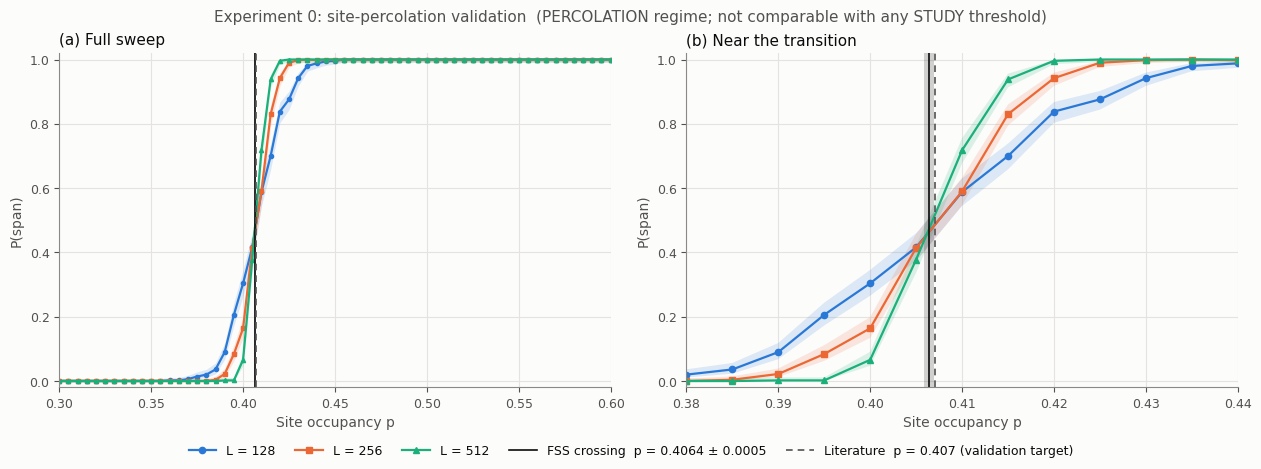

In [6]:
validation = FIGURES["validation"]()
validation

In [7]:
display(Markdown("**Caption.** " + CAPTIONS["validation"]))

**Caption.** Validation of the PERCOLATION regime (Experiment 0). Probability P(span) that a fire ignited along the top edge reaches the bottom edge, against site occupancy p, for L = 128, 256 and 512 (Moore neighbourhood; shaded bands are 95% Wilson intervals). (a) The full sweep. (b) The transition: the curves steepen with L and cross at the finite-size-scaling crossing (solid line, shaded to its standard error). The dashed line is the literature value P_C_LITERATURE = 0.407 for the 8-neighbour square lattice; it is a validation target only and enters no estimate. This threshold belongs to the PERCOLATION regime and is not comparable with any STUDY threshold.

**Reading the figure.** The two panels show the same curves. Panel (a) is the whole sweep: below roughly $p = 0.38$ fire essentially never spans the lattice and above roughly $p = 0.44$ it essentially always does. Panel (b) zooms on the transition, and this is where the finite-size-scaling argument is visible: the curves for $L = 128$, $256$ and $512$ pivot about a common point, with larger lattices steeper on either side of it. The solid vertical line is the crossing the analysis extracted and the dashed line is the literature value. The estimate is drawn on the plot; the numbers behind it are computed next from `results/pc_estimates.parquet`.

In [8]:
pc = pd.read_parquet(ROOT / "results" / "pc_estimates.parquet")
perc = pc[(pc["regime"] == "PERCOLATION") & (pc["condition"] == "none")
          & (pc["b"] == 0.0) & (pc["kappa"] == 0.0)].copy()
perc["L"] = perc["L"].astype(object).where(perc["L"].notna(), "all L")
perc["p_c - literature"] = perc["p_c"] - P_C_LITERATURE
display(perc[["method", "L", "p_c", "p_c_stderr", "p_c - literature"]]
        .set_index("method").style.format(precision=4))

crossing = perc[perc["method"] == "fss_crossing"].iloc[0]
peak512 = perc[(perc["method"] == "var_peak") & (perc["L"] == 512)].iloc[0]
gap = crossing["p_c"] - P_C_LITERATURE
display(Markdown(
    f"**FSS crossing:** $p_c = {crossing['p_c']:.4f} \\pm {crossing['p_c_stderr']:.4f}$ against the literature "
    f"${P_C_LITERATURE}$, a difference of ${gap:+.4f}$ (**{gap / crossing['p_c_stderr']:+.1f}** bootstrap standard "
    f"errors). The invariant I1 tolerance is $0.01$, so the estimate passes with a margin of "
    f"${0.01 - abs(gap):.4f}$.  \n"
    f"**Cross-check:** the $L=512$ variance peak is ${peak512['p_c']:.4f}$ "
    f"(${peak512['p_c'] - P_C_LITERATURE:+.4f}$ from the literature), reported alongside and not asserted."))

,L,p_c,p_c_stderr,p_c - literature
method,,,,
var_peak,128,0.4105,0.0007,0.0035
var_peak,256,0.4088,0.0004,0.0018
var_peak,512,0.4075,0.0005,0.0005
fss_crossing,all L,0.4064,0.0005,-0.0006


**FSS crossing:** $p_c = 0.4064 \pm 0.0005$ against the literature $0.407$, a difference of $-0.0006$ (**-1.1** bootstrap standard errors). The invariant I1 tolerance is $0.01$, so the estimate passes with a margin of $0.0094$.  
**Cross-check:** the $L=512$ variance peak is $0.4075$ ($+0.0005$ from the literature), reported alongside and not asserted.

**Interpretation.**

- The measured crossing sits very close to the literature threshold of 0.407: well inside the tolerance the test suite asserts (I1), and statistically close to it too (the difference in bootstrap standard errors is printed above). The model, the experiment harness and the estimator therefore recover one independently known result, which is the evidence that the machinery is right before any substantive experiment relies on it.
- The variance peaks show the finite-size shift the method is designed to avoid: each size's peak lies above the literature value and moves towards it as $L$ grows ($L = 128$, $256$, $512$ in the table). A single-size peak is a biased estimate of the infinite-lattice threshold; the crossing across sizes is the better one, and that is why it is the governing value.
- **This threshold is a validation result and nothing more.** It is the $p_c$ of the `PERCOLATION` regime, where $\beta = 1$, $\kappa = 0$ and the diagonal factor is off. The `STUDY` regime has different rule parameters and therefore a different threshold, which is measured separately for every condition. The two are different by construction and are **not comparable**, so the `PERCOLATION` value must never be used as a stand-in for a `STUDY` threshold, and `P_C_LITERATURE` is used in exactly one place in the project: the check that this validation passed.

## Where this goes next

The `STUDY` regime, with wind, the diagonal factor and treatment geometries, is what the remaining experiments explore. Their results are presented in notebooks 02 and 03, which consume the same figure registry and, unlike part 4 of this notebook, never run the simulator.